In [5]:
import pandas as pd
import seaborn as sns

## Clean duplicate functions and docstrings

In [6]:
all_data = pd.read_csv('data/Menagerie/data/docstring_code_grades.csv', index_col=0)
all_data = all_data[~all_data['docstring_summary'].isna()]
all_data['grade'] = pd.Categorical(all_data['grade'],
                                   ['A++', 'A+', 'A', 'A-',
                                    'B+', 'B', 'B-',
                                    'C+', 'C', 'C-',
                                    'D+', 'D', 'D-',
                                    'F'])
# all_data['grade'] = all_data['grade'].apply(lambda x: x[0])

In [7]:
print(all_data.shape)
all_data.head()

(28354, 10)


,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156


In [8]:
all_data['grade'].value_counts()

grade
A      9673
B+     5902
A-     5359
A+     3985
B      1443
B-      869
A++     459
F       260
C       199
D+       52
D        52
D-       52
C+       49
C-        0
Name: count, dtype: int64

In [9]:
def transform_values(row):
    grades = set(list(row['grade']))
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grade': str(grades), 'grade_count': len(grades)}
    return pd.Series(output, index=['docstring', 'function', 'grade', 'grade_count'])

def hash_code_docstring_pairs(row):
    code_ds_pair = row['docstring'] + '\n' + row['function']
    return hash(code_ds_pair)

In [10]:
# Hash generated on tokens to remove whitespace causing unique values
all_data['hash'] = all_data.apply(hash_code_docstring_pairs, axis=1)
duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)
duplicate_value_df[duplicate_value_df['grade_count'] > 1].head()

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_61344/163026546.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)


,docstring,function,grade,grade_count
hash,,,,
-9206494022255255336,Check if new plants will be created\n@param ne...,private void makeNewPlants(List<LivingBeing> n...,"{'A+', 'A'}",2
-9048610905922202576,Determine whether the simulation is still viab...,public boolean isViable(Field field)\n {\n ...,"{'F', 'B', 'A-', 'B+', 'B-', 'D', 'A+', 'A++',...",13
-9017431619959343750,A hedgehog can breed if it has reached the bre...,private boolean canBreed()\n {\n ret...,"{'A+', 'A'}",2
-8965296653857494445,Return the width of the field.\n\n@return The ...,public int getWidth()\n {\n return w...,"{'A+', 'B', 'A-', 'A'}",4
-8954057616032829914,Use the top 16 bits for the row value and the ...,public int hashCode() {\n return (row <...,"{'A-', 'B-', 'B+', 'A'}",4


<Axes: xlabel='grade', ylabel='count'>

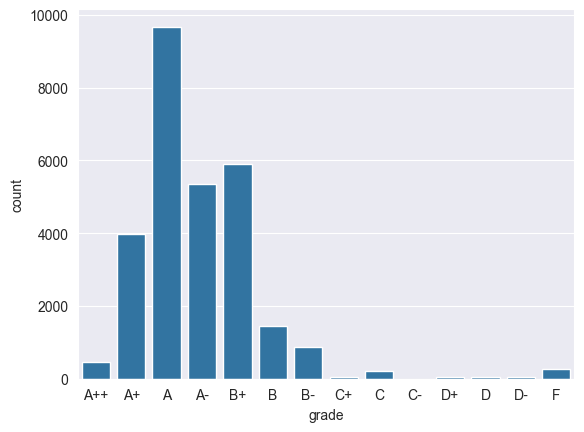

In [11]:
sns.countplot(all_data, x='grade')

### Find Consensus

In [12]:
print(all_data.shape)
all_data.head()

(28354, 11)


,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers,hash
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81,8934452335535591611
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97,-2573534589695175808
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108,1923792112077657946
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134,-1333726992489484964
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156,1525491188124019553


In [13]:
def find_consensus(row):
    grades = list(row['grade'])
    
    grade_dict = {}
    
    for grade in grades:
        if grade not in grade_dict.keys():
            grade_dict[grade] = 1
        else:
            grade_dict[grade] += 1
             
    if len(grade_dict) == 1:
        grade_consensus = list(grade_dict.keys())[0]
    elif all(count == list(grade_dict.values())[0] for count in grade_dict.values()):
        
        grade_consensus = None
    else:
        grade_consensus = max(grade_dict, key=grade_dict.get)
    
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grades': grade_dict, 'grade_count': len(grades), 'grade': grade_consensus}
    return pd.Series(output, index=['docstring', 'function', 'grades', 'grade_count', 'grade'])

In [14]:
unique_consensus_df = all_data.groupby('hash').apply(find_consensus)
unique_consensus_df[unique_consensus_df['grade_count'] > 3].head(100)
# unique_consensus_df

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_61344/2947905652.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_consensus_df = all_data.groupby('hash').apply(find_consensus)


,docstring,function,grades,grade_count,grade
hash,,,,,
-9048610905922202576,Determine whether the simulation is still viab...,public boolean isViable(Field field)\n {\n ...,"{'A': 72, 'B+': 53, 'F': 5, 'A-': 33, 'B': 11,...",209,A
-8965296653857494445,Return the width of the field.\n\n@return The ...,public int getWidth()\n {\n return w...,"{'A+': 3, 'B': 1, 'A-': 1, 'A': 2}",7,A+
-8954057616032829914,Use the top 16 bits for the row value and the ...,public int hashCode() {\n return (row <...,"{'B-': 1, 'B+': 2, 'A': 1, 'A-': 3}",7,A-
-8912211965015524610,{@inheritDoc},@Override\n protected int getMaxNewInstance...,{'A-': 5},5,A-
-8882345748969514657,Return the maximum level of sickness.\n@return...,public int getMaxSicknessLevel() {\n re...,{'A': 5},5,A
...,...,...,...,...,...
-5085115845508867753,Accessor method for the food source\n@return f...,public Class getFoodSource()\n {\n r...,{'A-': 4},4,A-
-5063718275663513268,Indicate that an animal count has been completed.,public void countFinished() {\n countsV...,"{'A-': 4, 'B-': 1, 'B+': 3, 'A': 2}",10,A-
-5040924098848453546,Change the breeding probability of a fieldobje...,public static void setBreedingProbability(doub...,{'A': 7},7,A


In [15]:
(unique_consensus_df[unique_consensus_df['grade'].isna()].shape[0] / unique_consensus_df.shape[0]) * 100

1.7029049555123446

(16682, 5)
(16682, 5)


<Axes: xlabel='grade'>

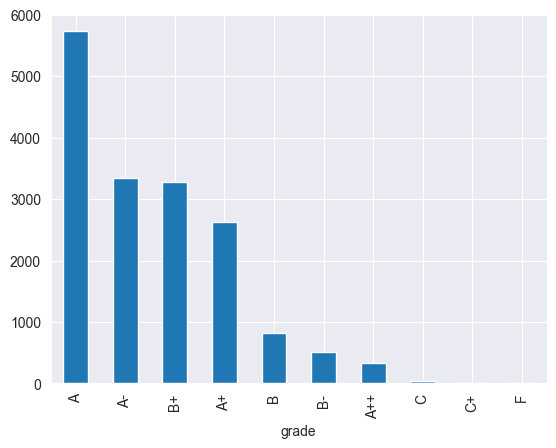

In [18]:
print(unique_consensus_df.shape)
unique_consensus_df = unique_consensus_df[~unique_consensus_df['grade'].isna()]
print(unique_consensus_df.shape)
unique_consensus_df['grade'].value_counts()

[Text(0, 0, '5728'),
 Text(0, 0, '2620'),
 Text(0, 0, '330'),
 Text(0, 0, '3345'),
 Text(0, 0, '815'),
 Text(0, 0, '3285'),
 Text(0, 0, '507'),
 Text(0, 0, '38'),
 Text(0, 0, '12'),
 Text(0, 0, '2')]

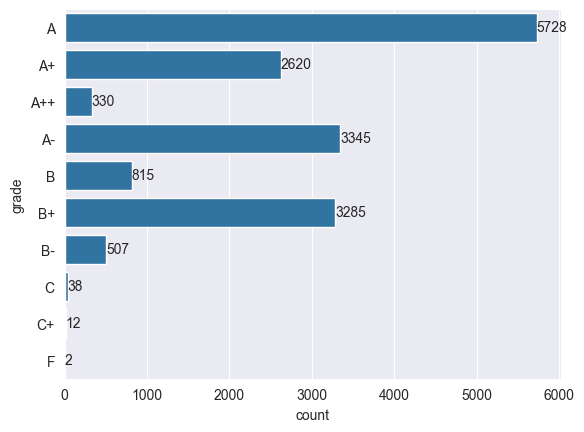

In [21]:
ax = sns.countplot(unique_consensus_df['grade'].sort_values())
ax.bar_label(ax.containers[0])

In [13]:
# Filter out F and merge C - too few samples

unique_consensus_df = unique_consensus_df[unique_consensus_df['grade'] != 'F']
unique_consensus_df['grade'] = unique_consensus_df['grade'].apply(lambda g: g[0] if g[0] == 'C' else g)
unique_consensus_df['grade'].value_counts()

grade
A    12213
B     4585
C       50
Name: count, dtype: int64

In [14]:
unique_consensus_df.head()

,docstring,function,grades,grade_count,grade
hash,,,,,
-9221898114426795719,Set the rainfall multiplier.\n@param rainfallM...,public void setRainfallMultiplier(double rainf...,{'B': 1},1,B
-9220628756647546455,Checks if this KCLSU can breed with the given ...,protected boolean canBreed(Animal animal)\n ...,{'B': 1},1,B
-9219725629085720538,A method to identify the encountered animal.\n...,"private boolean identifyAnimal(Object animal,L...",{'A': 1},1,A
-9219525520315648389,Generate a number representing the number of b...,private int breed()\n {\n int births...,{'B': 1},1,B
-9219186351815834129,Make the power socket charge every prey next t...,public void charge() { \n List<Locat...,{'B': 1},1,B


In [15]:
unique_consensus_df.to_csv('data/menagerie_unique_pairs_truncated.csv')